# Basic WSSS pipeline

Just dino + decoder

In [8]:
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

from dataset import (
    make_voc_datasets,
    VOC_CLASSES,
    colorize,
    denorm_to_uint8,
    get_wsss_dataloaders,
    cache_dino_tokens,
    wsss_collate_fn,
    evaluate_masks,
)

In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
BASIC_CHECKPOINT = "basic_checkpoint.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading DINOv3 (ViT-Small)...")
dino_model = torch.hub.load(
    "./dinov3", "dinov3_vits16", source="local",
    weights="weights/dinov3_vits16_pretrain_lvd1689m-08c60483.pth",
).to(device)
dino_model.eval()

train_ds, val_ds = make_voc_datasets(root="./data", resize_size=IMG_SIZE)
_, train_cache_loader, val_loader = get_wsss_dataloaders(
    train_ds=train_ds, val_ds=val_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
)

## Classifier head

Frozen DINOv3 -> GAP over patch tokens

In [10]:
NUM_CLASSES = 20
EMBED_DIM = dino_model.embed_dim
PATCH_SIZE = dino_model.patch_size
GRID = IMG_SIZE // PATCH_SIZE
NUM_PATCHES = GRID * GRID


class CAMClassifier(nn.Module):
    """
    A single linear classifier
    """

    def __init__(self, embed_dim: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(embed_dim, num_classes, bias=True)

    def forward(self, patch_tokens: torch.Tensor) -> torch.Tensor:
        pooled = patch_tokens.mean(dim=1)
        return self.fc(pooled)

    @torch.no_grad()
    def cam(self, patch_tokens: torch.Tensor, grid: int) -> torch.Tensor:
        """
        Raw CAM on the patch grid: [B, C, grid, grid] (no normalization).
        Similar to Zhou et al., CVPR 2016
        """
        B, P, D = patch_tokens.shape
        feats = patch_tokens.transpose(1, 2).reshape(B, D, grid, grid)
        W = self.fc.weight
        cams = F.conv2d(feats, W.unsqueeze(-1).unsqueeze(-1))
        return cams
        
    @torch.no_grad()
    def predict(self, patch_tokens: torch.Tensor, grid: int, target_size: tuple[int, int], image_labels: torch.Tensor, bg_threshold: float = 0.25):
        """
        Produce a discrete mask via ReLU, min-max normalization, gating by label, and argmaxing against background.
        Returns:
            cams: [B, C, H, W] normalized CAM mask
            preds: [B, H, W] integer predictions (0..20)
        """
        cams = self.cam(patch_tokens.float(), grid)
        cams = F.relu(cams)
        cams = F.interpolate(cams, size=target_size, mode="bilinear", align_corners=False)

        B, C, H, W = cams.shape
        flat = cams.view(B, C, -1)
        cmin = flat.min(dim=2, keepdim=True).values
        cmax = flat.max(dim=2, keepdim=True).values
        flat = (flat - cmin) / (cmax - cmin).clamp(min=1e-6)
        cams = flat.view_as(cams)

        mask = image_labels.view(B, C, 1, 1)
        cams = cams * mask

        bg = torch.full((B, 1, H, W), bg_threshold, device=cams.device, dtype=cams.dtype)
        full = torch.cat([bg, cams], dim=1)
        preds = full.argmax(dim=1)
        
        return cams, preds

classifier = CAMClassifier(EMBED_DIM, NUM_CLASSES).to(device)
print(classifier)

CAMClassifier(
  (fc): Linear(in_features=384, out_features=20, bias=True)
)


## Cache DINO patch tokens

DINO is frozen, so we extract patch tokens once and keep them on device

In [11]:
train_tokens, train_labels = cache_dino_tokens(
    dino_model, train_ds, train_cache_loader, device=device
)
val_tokens, val_labels = cache_dino_tokens(
    dino_model, val_ds, val_loader, device=device
)

Caching DINO:   0%|          | 0/46 [00:00<?, ?it/s]

Caching DINO: Cached 1464 samples (0.21 GB on cuda).


Caching DINO:   0%|          | 0/46 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fdab0e71bc0>
Traceback (most recent call last):
  File "/home/andrey/projects/cs484-wsss/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/home/andrey/projects/cs484-wsss/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7fdab0e71bc0>^
^Traceback (most recent call last):
^  File "/home/andrey/projects/cs484-wsss/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^self._shutdown_workers()^
^  File "/home/andrey/projects/cs484-wsss/.venv/lib/python3.12

Caching DINO: Cached 1449 samples (0.20 GB on cuda).


## Train the classifier

NN things

In [ ]:
EPOCHS       = 30
LR           = 1e-3
WEIGHT_DECAY = 1e-4
BASIC_CHECKPOINT = "basic_checkpoint.pth"

classifier = CAMClassifier(EMBED_DIM, NUM_CLASSES).to(device)
optimizer  = AdamW(classifier.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = CosineAnnealingLR(optimizer, T_max=EPOCHS)
bce_loss   = nn.BCEWithLogitsLoss()


def cached_batches(tokens, labels, batch_size, shuffle=True):
    n = tokens.shape[0]
    order = torch.randperm(n, device=tokens.device) if shuffle else torch.arange(n, device=tokens.device)
    for i in range(0, n, batch_size):
        idx = order[i : i + batch_size]
        yield tokens[idx].float(), labels[idx]


epoch_losses = []
for epoch in range(1, EPOCHS + 1):
    classifier.train()
    epoch_loss, n_seen = 0.0, 0
    for x, y in cached_batches(train_tokens, train_labels, BATCH_SIZE):
        optimizer.zero_grad()
        loss = bce_loss(classifier(x), y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
        n_seen += x.size(0)
    scheduler.step()
    avg = epoch_loss / n_seen
    epoch_losses.append(avg)
    print(f"epoch {epoch:02d}/{EPOCHS} | loss {avg:.4f}")

torch.save({
    'epoch': EPOCHS,
    'model_state_dict': classifier.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch_losses': epoch_losses,
}, BASIC_CHECKPOINT)
print(f"Checkpoint saved to {BASIC_CHECKPOINT}")

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.title('Basic WSSS — Training Loss')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss'); plt.grid(True)
plt.show()

## Visualize CAMs

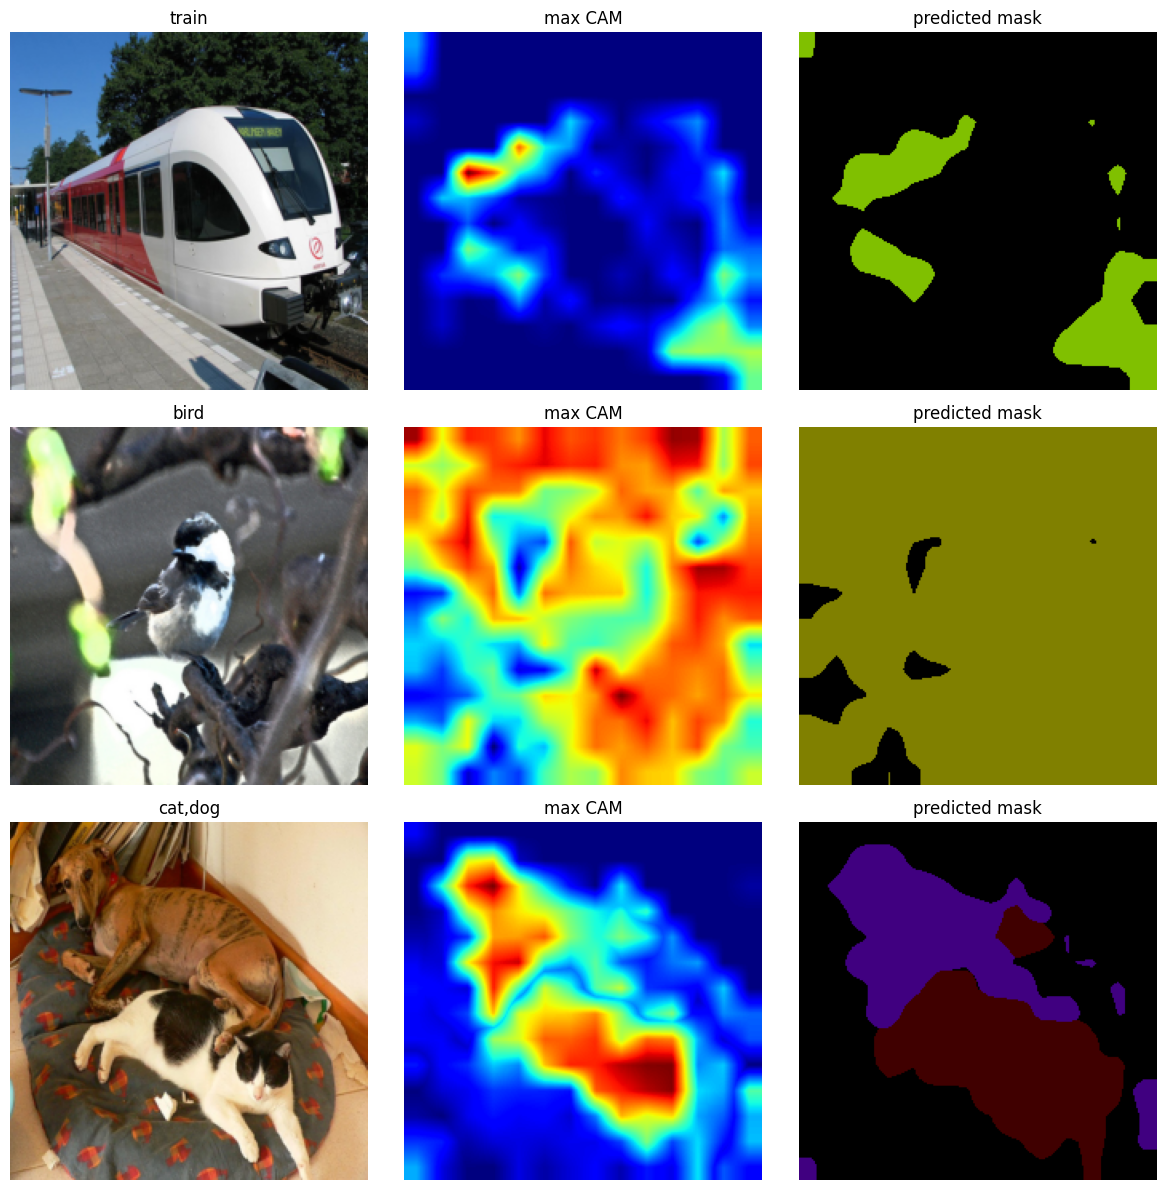

In [13]:
def visualize(num_images: int = 3, seed: int = 0):
    rng = random.Random(seed)
    indices = rng.sample(range(len(val_ds)), num_images)

    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    if num_images == 1:
        axes = [axes]

    for row, idx in zip(axes, indices):
        _, img_t, label_vec, _ = val_ds[idx]
        img_batch = img_t.unsqueeze(0).to(device)
        label_batch = label_vec.unsqueeze(0).to(device)
        tokens = val_tokens[idx].unsqueeze(0).float()

        cams, raw_labels = classifier.predict(tokens, GRID, target_size=(IMG_SIZE, IMG_SIZE), image_labels=label_batch)
        raw_labels = raw_labels[0].cpu().numpy()

        present = [VOC_CLASSES[c] for c in torch.where(label_vec > 0)[0].tolist()]
        cam_vis = cams[0].max(dim=0).values.cpu().numpy()

        row[0].imshow(denorm_to_uint8(img_t)); row[0].set_title(",".join(present) or "(none)")
        row[1].imshow(cam_vis, cmap="jet", vmin=0, vmax=1); row[1].set_title("max CAM")
        row[2].imshow(colorize(raw_labels)); row[2].set_title("predicted mask")
        for ax in row:
            ax.axis("off")
    plt.tight_layout(); plt.show()


visualize(num_images=3)

## Validation mIoU

Score per-class IoU against ground-truth VOC masks for the raw CAM-argmax masks.

In [ ]:
# Load checkpoint — run independently of the training cell
ckpt = torch.load(BASIC_CHECKPOINT, map_location=device, weights_only=False)
classifier = CAMClassifier(EMBED_DIM, NUM_CLASSES).to(device)
classifier.load_state_dict(ckpt['model_state_dict'])
classifier.eval()
print(f"Loaded {BASIC_CHECKPOINT} (epoch {ckpt['epoch']})")

n_cls = NUM_CLASSES + 1
inter = np.zeros(n_cls, dtype=np.int64)
union = np.zeros(n_cls, dtype=np.int64)

for indices, images, labels, masks in tqdm(val_loader, desc="mIoU"):
    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)
    tokens = val_tokens[indices].float()
    _, preds = classifier.predict(tokens, GRID, (IMG_SIZE, IMG_SIZE), labels)
    for b in range(len(indices)):
        mask_t = masks[b].to(device)
        H, W = mask_t.shape
        p = F.interpolate(preds[b:b+1].float().unsqueeze(0), (H, W), mode="nearest-exact").squeeze()
        b_int, b_uni, _ = evaluate_masks(p, mask_t, num_classes=n_cls, ignore_index=255)
        inter += b_int.cpu().numpy().astype(np.int64)
        union += b_uni.cpu().numpy().astype(np.int64)

iou     = inter / np.maximum(union, 1)
present = union > 0
miou    = iou[present].mean()
print(f"\nmIoU = {miou:.4f}")
for c, name in enumerate(["background"] + VOC_CLASSES):
    if present[c]:
        print(f"  {name:<14s}  {iou[c]:.4f}")